In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import random
from skimage.filters import threshold_sauvola, threshold_niblack
from joblib import Parallel, delayed
import json
from datetime import datetime
import IPython.display as display
from PIL import Image
import io
import time
import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from skimage.feature import hog

%matplotlib inline

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [2]:
x = np.array([0.5,0.2, 0.8])
w = np.array([0.4, 0.7, 0.3])
b = 0.1
z = np.dot(x, w) + b
print(z)

0.6799999999999999


In [4]:
relu = max(0, z)
print(relu)

0.6799999999999999


In [7]:
# 1. Load CSV data (assuming standard format where 1st column is 'label' and remaining 784 columns are pixels)
train_df = pd.read_csv(r"C:\Users\PC-LAB1\img_processing_lab\day05\data\mnist\archive\mnist_train.csv")
test_df = pd.read_csv(r"C:\Users\PC-LAB1\img_processing_lab\day05\data\mnist\archive\mnist_test.csv")

# Separate labels (y) and pixel values (X)
y_train = train_df.iloc[:, 0].values
X_train_raw = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
X_test_raw = test_df.iloc[:, 1:].values

# 2. Preprocess & Reshape Data
# Scale pixel values from [0, 255] to [0.0, 1.0] for stable gradient descent
X_train = (X_train_raw / 255.0).reshape(-1, 28, 28)
X_test = (X_test_raw / 255.0).reshape(-1, 28, 28)

# 3. Define the MLP Architecture
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

# 4. Compile the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train the Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# 6. Evaluate Baseline Performance on Unseen Test Data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nBaseline MLP Test Accuracy: {test_acc * 100:.2f}%")

c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9240 - loss: 0.2581 - val_accuracy: 0.9662 - val_loss: 0.1151
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9665 - loss: 0.1090 - val_accuracy: 0.9723 - val_loss: 0.0939
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9766 - loss: 0.0748 - val_accuracy: 0.9727 - val_loss: 0.0892
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9813 - loss: 0.0577 - val_accuracy: 0.9765 - val_loss: 0.0816
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9856 - loss: 0.0448 - val_accuracy: 0.9785 - val_loss: 0.0789
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9879 - loss: 0.0367 - val_accuracy: 0.9770 - val_loss: 0.0902
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9905 - loss: 0.0297 - val_accuracy: 0.9787 - val_loss: 0.0866
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9917 - loss: 0.0253 - 

In [10]:
y_train = train_df.iloc[:, 0].values
X_train_raw = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
X_test_raw = test_df.iloc[:, 1:].values

# 2. Preprocess & Reshape Data for CNN (Add Explicit Channel Dimension)
# Reshape from (N, 784) to (N, 28, 28, 1) for grayscale
X_train = (X_train_raw / 255.0).reshape(-1, 28, 28, 1)
X_test = (X_test_raw / 255.0).reshape(-1, 28, 28, 1)

# 3. Define CNN Architecture
model = Sequential([
    # Layer 1: First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    # Layer 2: Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Layer 3: Classification Head
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Print detailed dimensions and parameter counts per layer
model.summary()

# 4. Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# 6. Evaluate CNN Performance
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nCNN Test Accuracy: {test_acc * 100:.2f}%")

c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9580 - loss: 0.1353 - val_accuracy: 0.9862 - val_loss: 0.0517
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9858 - loss: 0.0443 - val_accuracy: 0.9888 - val_loss: 0.0354
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9909 - loss: 0.0298 - val_accuracy: 0.9918 - val_loss: 0.0322
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9932 - loss: 0.0207 - val_accuracy: 0.9910 - val_loss: 0.0336
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9951 - loss: 0.0156 - val_accuracy: 0.9918 - val_loss: 0.0312
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9954 - loss: 0.0134 - val_accuracy: 0.9902 - val_loss: 0.0451
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9965 - loss: 0.0104 - val_accuracy: 0.9912 - val_loss: 0.0388
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9970 - loss: 0.

Loading data from        label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0          5    0    0    0    0    0    0    0    0    0  ...      0      0   
1          0    0    0    0    0    0    0    0    0    0  ...      0      0   
2          4    0    0    0    0    0    0    0    0    0  ...      0      0   
3          1    0    0    0    0    0    0    0    0    0  ...      0      0   
4          9    0    0    0    0    0    0    0    0    0  ...      0      0   
...      ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...    ...    ...   
59995      8    0    0    0    0    0    0    0    0    0  ...      0      0   
59996      3    0    0    0    0    0    0    0    0    0  ...      0      0   
59997      5    0    0    0    0    0    0    0    0    0  ...      0      0   
59998      6    0    0    0    0    0    0    0    0    0  ...      0      0   
59999      8    0    0    0    0    0    0    0    0    0  ...      0      0   

       28x21  28x22  

c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9239 - loss: 0.2563 - val_accuracy: 0.9677 - val_loss: 0.1101
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9672 - loss: 0.1084 - val_accuracy: 0.9768 - val_loss: 0.0801
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9776 - loss: 0.0746 - val_accuracy: 0.9763 - val_loss: 0.0836
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9816 - loss: 0.0572 - val_accuracy: 0.9767 - val_loss: 0.0852
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9859 - loss: 0.0439 - val_accuracy: 0.9793 - val_loss: 0.0753
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9882 - loss: 0.0364 - val_accuracy: 0.9787 - val_loss: 0.0802
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9902 - loss: 0.0295 - val_accuracy: 0.9790 - val_loss: 0.0862
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9917 - loss: 0.0248 - val_accurac

c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9589 - loss: 0.1358 - val_accuracy: 0.9810 - val_loss: 0.0610
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9860 - loss: 0.0451 - val_accuracy: 0.9877 - val_loss: 0.0416
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9902 - loss: 0.0305 - val_accuracy: 0.9912 - val_loss: 0.0368
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - accuracy: 0.9926 - loss: 0.0222 - val_accuracy: 0.9898 - val_loss: 0.0322
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - accuracy: 0.9943 - loss: 0.0160 - val_accuracy: 0.9908 - val_loss: 0.0344
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9961 - loss: 0.0118 - val_accuracy: 0.9917 - val_loss: 0.0336
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9965 - loss: 0.0105 - val_accuracy: 0.9875 - val_loss: 0.0563
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9970 - loss: 0.

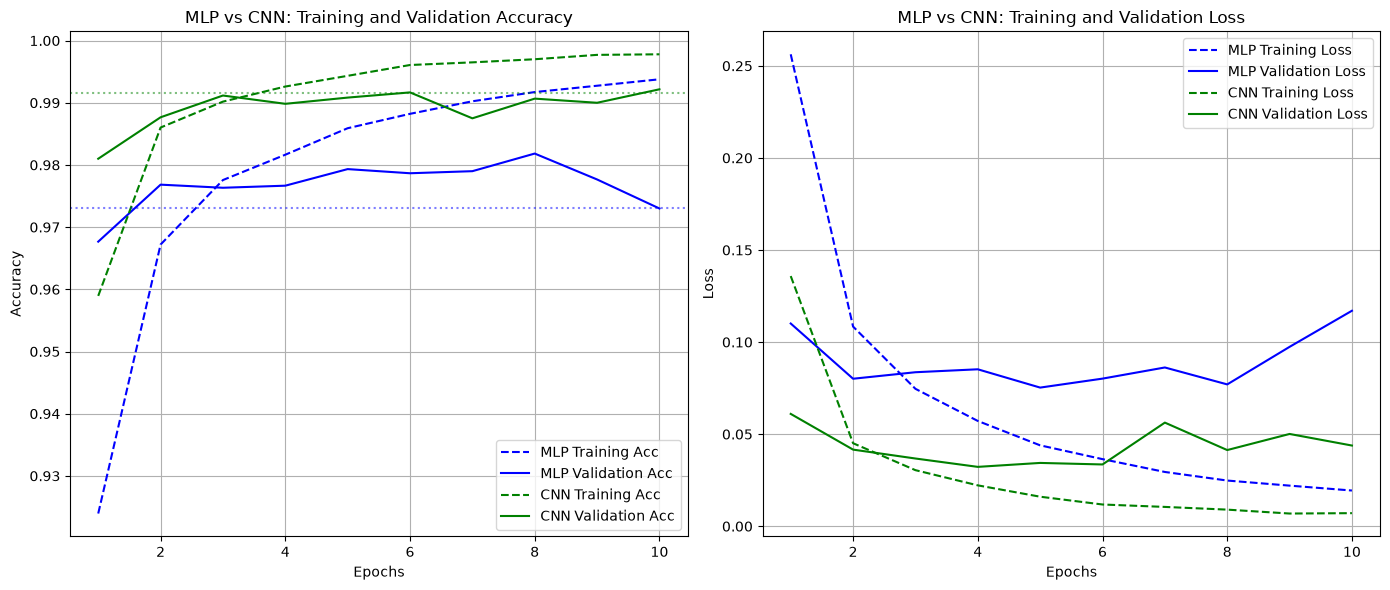


      FINAL COMPARISON SUMMARY
MLP (Baseline) Test Accuracy: 0.9730
CNN (Replacement) Test Accuracy: 0.9915
Improvement: 1.85 percentage points


In [12]:
# --- 1. DEFINE DATA LOADING FUNCTION ---
# We use a function to ensure we get a fresh, clean load and normalize for each model.
def load_and_preprocess_mnist_csv(train_csv_path, test_csv_path, reshape_dims=None):
    """
    Loads MNIST from CSV, normalizes, and optionally reshapes (e.g., for CNN).
    Assuming: column 0 is 'label', columns 1-784 are pixel values.
    """
    print(f"Loading data from {train_csv_path} and {test_csv_path}...")
    try:
        train_df = pd.read_csv(r"C:\Users\PC-LAB1\img_processing_lab\day05\data\mnist\archive\mnist_train.csv")
        test_df = pd.read_csv(r"C:\Users\PC-LAB1\img_processing_lab\day05\data\mnist\archive\mnist_test.csv")
    except FileNotFoundError:
        print("Error: MNIST CSV files not found. Please ensure they are present.")
        return None, None, None, None

    # Separate X (pixels) and y (labels)
    y_train_raw = train_df.iloc[:, 0].values
    X_train_raw = train_df.iloc[:, 1:].values
    y_test_raw = test_df.iloc[:, 0].values
    X_test_raw = test_df.iloc[:, 1:].values

    # Normalize: Convert from int8 [0, 255] to float32 [0.0, 1.0]
    X_train = X_train_raw.astype('float32') / 255.0
    X_test = X_test_raw.astype('float32') / 255.0

    # Reshape if required
    if reshape_dims:
        X_train = X_train.reshape((-1,) + reshape_dims)
        X_test = X_test.reshape((-1,) + reshape_dims)

    return (X_train, y_train_raw), (X_test, y_test_raw)


# --- 2. TRAIN BASELINE MLP ---
# Setup for MLP (requires Flattening first)
(X_train_mlp, y_train), (X_test_mlp, y_test) = load_and_preprocess_mnist_csv(train_df, test_df, reshape_dims=(28, 28))

if X_train_mlp is not None:
    print("\n--- Training Baseline MLP ---")
    model_mlp = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model_mlp.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

    # Standard training setup
    history_mlp = model_mlp.fit(
        X_train_mlp, y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=1
    )
    test_loss_mlp, test_acc_mlp = model_mlp.evaluate(X_test_mlp, y_test, verbose=0)
else:
    history_mlp = None


# --- 3. TRAIN REPLACEMENT CNN ---
# Setup for CNN (requires 4D shape: batch, height, width, channel)
(X_train_cnn, y_train), (X_test_cnn, y_test) = load_and_preprocess_mnist_csv('mnist_train.csv', 'mnist_test.csv', reshape_dims=(28, 28, 1))

if X_train_cnn is not None:
    print("\n--- Training Replacement CNN ---")
    model_cnn = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])

    # Show CNN details to confirm the structure requested
    model_cnn.summary()

    model_cnn.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

    # Match the identical training setup
    history_cnn = model_cnn.fit(
        X_train_cnn, y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=1
    )
    test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)
else:
    history_cnn = None


# --- 4. CREATE SIDE-BY-SIDE PLOTS ---
if history_mlp and history_cnn:
    epochs = range(1, 11) # Assuming 10 epochs

    plt.figure(figsize=(14, 6))

    # --- Plot Accuracy ---
    plt.subplot(1, 2, 1) # (rows, columns, panel number)
    plt.plot(epochs, history_mlp.history['accuracy'], label='MLP Training Acc', color='blue', linestyle='--')
    plt.plot(epochs, history_mlp.history['val_accuracy'], label='MLP Validation Acc', color='blue', linestyle='-')
    plt.plot(epochs, history_cnn.history['accuracy'], label='CNN Training Acc', color='green', linestyle='--')
    plt.plot(epochs, history_cnn.history['val_accuracy'], label='CNN Validation Acc', color='green', linestyle='-')
    plt.title('MLP vs CNN: Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Add final test markers (optional, helpful context)
    plt.axhline(y=test_acc_mlp, color='blue', linestyle=':', alpha=0.5)
    plt.axhline(y=test_acc_cnn, color='green', linestyle=':', alpha=0.5)
    # plt.annotate(f'MLP Test: {test_acc_mlp:.3f}', xy=(10, test_acc_mlp), xytext=(8, test_acc_mlp-0.03), color='blue') # Adjust positioning manually
    # plt.annotate(f'CNN Test: {test_acc_cnn:.3f}', xy=(10, test_acc_cnn), xytext=(8, test_acc_cnn+0.01), color='green')


    # --- Plot Loss ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_mlp.history['loss'], label='MLP Training Loss', color='blue', linestyle='--')
    plt.plot(epochs, history_mlp.history['val_loss'], label='MLP Validation Loss', color='blue', linestyle='-')
    plt.plot(epochs, history_cnn.history['loss'], label='CNN Training Loss', color='green', linestyle='--')
    plt.plot(epochs, history_cnn.history['val_loss'], label='CNN Validation Loss', color='green', linestyle='-')
    plt.title('MLP vs CNN: Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout() # Adjust subplots to fit figures neatly
    print("\nDisplaying comparison plots...")
    plt.show()

    # --- 5. PRINT SUMMARY COMPARISON ---
    print("\n" + "="*40)
    print("      FINAL COMPARISON SUMMARY")
    print("="*40)
    print(f"MLP (Baseline) Test Accuracy: {test_acc_mlp:.4f}")
    print(f"CNN (Replacement) Test Accuracy: {test_acc_cnn:.4f}")
    print(f"Improvement: {(test_acc_cnn - test_acc_mlp)*100:.2f} percentage points")
    print("="*40)

else:
    print("\nSkipping visualization: At least one model did not train.")